# Анализ ассортимента методом ABC/XYZ

**Британский интернет-магазин подарков и товаров для дома**
Период анализа: декабрь 2010 — ноябрь 2011 | Данные: UCI Online Retail II

---

## Бизнес-задача

Ассортимент магазина постепенно расширялся, и теперь компания поддерживает большое количество SKU. Руководство считает, что часть товаров продаётся редко, занимает место на складе и усложняет закупки. Рассматривается сокращение ассортимента примерно на 20%, но перед этим нужно оценить риски.

## Главный вопрос проекта

Какие товары необходимо **постоянно держать** в ассортименте, какие требуют **осторожного управления запасами**, а какие можно рассматривать как **кандидатов на сокращение или вывод** — и какой потенциальный эффект даст такое решение?

## Цель

Оценить структуру ассортимента и предложить правила управления товарными позициями, включая обоснованный список SKU-кандидатов на сокращение, с оценкой эффекта и рисков.

## Задачи

1. **Знакомство с данными.** Оценить размер, типы, временной диапазон; выявить и осознанно обработать аномалии (отмены, отрицательные количества, нулевые цены, служебные коды, дубликаты).
2. **Базовая картина бизнеса.** Рассчитать ключевые метрики (SKU, заказы, покупатели, выручка, средний чек на уровне заказа), помесячную динамику и концентрацию выручки.
3. **ABC-анализ по выручке.** Разделить товары на группы A / B / C по накопительной доле выручки.
4. **XYZ-анализ по вариативности спроса.** Для каждого SKU построить полный 12-месячный ряд количества (с нулями) и рассчитать CV.
5. **Матрица ABC/XYZ.** Сформировать 9 групп (AX…CZ) и посчитать бизнес-метрики по каждой.
6. **Стратегия управления.** Сформулировать правила для каждой группы.
7. **Список кандидатов на сокращение.** Разработать критерии отбора с учётом ABC/XYZ и дополнительных метрик.
8. **Оценка эффекта.** Посчитать долю SKU и долю выручки кандидатов, проверить устойчивость решения.


## Данные

- **Источник:** UCI Machine Learning Repository — Online Retail II.
- **Период:** 12 полных последовательных месяцев (декабрь 2010 — ноябрь 2011).
- **Одна строка** — позиция в счёте/заказе. Присутствуют отмены, отрицательные количества, пропуски и другие особенности реальных данных.
- **Ключевые поля:** InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country.

## Ограничения исследования

Анализ построен на транзакционных данных. Для окончательного операционного решения **не хватает**:
- себестоимости и маржи;
- данных об остатках и out-of-stock (**продажи ≠ истинный спрос** — ноль продаж может означать отсутствие товара на складе, а не отсутствие интереса);
- стоимости хранения, сроков поставки, минимальных партий;
- данных о возвратах, сроке годности и роли товара в корзине.

In [1]:
#Загружаем библиотеки
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress, kruskal, mannwhitneyu, pearsonr, spearmanr
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols
from itertools import combinations

In [2]:
# Загружаем данные
file_path =r'C:\Users\Дмитрий\Desktop\online+retail+ii\online_retail_II.xlsx'

sheet1 = pd.read_excel(file_path, sheet_name='Year 2009-2010')
sheet2 = pd.read_excel(file_path, sheet_name='Year 2010-2011')

df = pd.concat([sheet1, sheet2], ignore_index=True)

print('Размер исходной таблицы:', df.shape)
df.head()


Размер исходной таблицы: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Смотрим информацию о типах данных и количество полей датафрейма
df.info()
print('\nДиапазон дат:', df['InvoiceDate'].min(), '—', df['InvoiceDate'].max())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB

Диапазон дат: 2009-12-01 07:45:00 — 2011-12-09 12:50:00


In [4]:
# Смотрим наличие пропусков 
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [5]:
# Смотрим наличие дубликатов
print('Полных дубликатов:', df.duplicated().sum())

Полных дубликатов: 34335


In [6]:
# Смотрим наличие отрицательных количеств едениц товара и счета с отменами (префикс С)
print('Отрицательный Quantity:', (df['Quantity'] < 0).sum())
print('Счета с префиксом C (отмены):', df['Invoice'].astype(str).str.startswith('C').sum())

Отрицательный Quantity: 22950
Счета с префиксом C (отмены): 19494


In [7]:
# Смотрим наличие нулевых и отрицательных цен за еденицу товара
print('Price == 0:', (df['Price'] == 0).sum())
print('Price < 0:', (df['Price'] < 0).sum())
df['Price'].describe()

Price == 0: 6202
Price < 0: 5


count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04
Name: Price, dtype: float64

In [8]:
# Проверяем наличие не стандартных кодов товарной позиции (SKU)
special = df[~df['StockCode'].astype(str).str.match(r'^\d{5}')]['StockCode'].unique()
print('Нестандартных кодов:', len(special))
print(sorted(special)[:40])

Нестандартных кодов: 62
['ADJUST', 'ADJUST2', 'AMAZONFEE', 'B', 'BANK CHARGES', 'C2', 'C3', 'CRUK', 'D', 'DCGS0003', 'DCGS0004', 'DCGS0006', 'DCGS0016', 'DCGS0027', 'DCGS0036', 'DCGS0037', 'DCGS0039', 'DCGS0041', 'DCGS0044', 'DCGS0053', 'DCGS0055', 'DCGS0056', 'DCGS0057', 'DCGS0058', 'DCGS0059', 'DCGS0060', 'DCGS0062', 'DCGS0066N', 'DCGS0066P', 'DCGS0067', 'DCGS0068', 'DCGS0069', 'DCGS0070', 'DCGS0071', 'DCGS0072', 'DCGS0073', 'DCGS0074', 'DCGS0075', 'DCGS0076', 'DCGSLBOY']


In [9]:
# Смотрим отрицательные цены
df[df['Price'] < 0][['Invoice','StockCode','Description','Quantity','Price']]

,Invoice,StockCode,Description,Quantity,Price
179403,A506401,B,Adjust bad debt,1,-53594.36
276274,A516228,B,Adjust bad debt,1,-44031.79
403472,A528059,B,Adjust bad debt,1,-38925.87
825444,A563186,B,Adjust bad debt,1,-11062.06
825445,A563187,B,Adjust bad debt,1,-11062.06


In [10]:
# Смотрим дорогие цены
df[df['Price'] > 1000][['Invoice','StockCode','Description','Quantity','Price']].head(10)

,Invoice,StockCode,Description,Quantity,Price
9307,C490129,M,Manual,-1,1998.49
22960,491176,M,Manual,1,1213.02
56523,C494477,M,Manual,-1,1747.62
62735,494918,DOT,DOTCOM POSTAGE,1,1081.70
65448,C495234,M,Manual,-1,1193.89
65449,495235,M,Manual,1,1193.89
71077,495798,ADJUST,Adjustment by john on 26/01/2010 17,1,5117.03
74356,496115,M,Manual,1,8985.60
74357,C496116,M,Manual,-1,8985.60
74358,C496118,M,Manual,-1,1065.54


In [11]:
# Смотрим пересекаются ли C-счета и отрицательный Quantity
c_mask = df['Invoice'].astype(str).str.startswith('C')
print('С C и отрицательным Quantity:', (c_mask & (df['Quantity'] < 0)).sum())
print('Отриц. Quantity без C:', ((df['Quantity'] < 0) & ~c_mask).sum())
print('C, но Quantity > 0:', (c_mask & (df['Quantity'] > 0)).sum())

С C и отрицательным Quantity: 19493
Отриц. Quantity без C: 3457
C, но Quantity > 0: 1


In [12]:
# Смотрим количество строс с нестандартным кодом StockCode
special = df[~df['StockCode'].astype(str).str.match(r'^\d{5}')]
special['StockCode'].value_counts().head(15)
print('Всего строк со служебными кодами:', len(special))
print('Доля от всех строк: {:.2%}'.format(len(special) / len(df)))

Всего строк со служебными кодами: 6093
Доля от всех строк: 0.57%


1. Отмены и отрицательные операции. Удаляем строки, где Invoice начинается с C (19 494 шт., подтверждено — это возвраты) или Quantity < 0 (22 950 шт., включая 3 457 строк без C). Обоснование: не формируют продажи и искажают спрос.

2. Цены. Удаляем Price <= 0 (6 207 строк). Обоснование: не дают корректной выручки, это бесплатные позиции и бухгалтерские списания (B / Adjust bad debt, Price < 0).

3. Служебные StockCode. Удаляем всё, что не является 5-значным числовым кодом (6 093 строки, 0,57%): POST, DOT, M, B, BANK CHARGES, AMAZONFEE, ADJUST, CRUK, DCGS*, C2, C3, D, S и др. Обоснование: это услуги/корректировки, а не товары.

4. Дубликаты. Удаляем полные дубли строк (34 335 шт.). Обоснование: технические повторы выгрузки, искажают подсчёты.

5. Пропуски Description (4 382) — оставляем. Ключ анализа — StockCode; описание подтянем из других строк того же SKU при выводе списка кандидатов.

6. Пропуски Customer ID (243 007, 23%) — оставляем. ABC/XYZ считаем по товарам, клиент нужен лишь для дополнительных метрик, где пропуск допустим.

7. Выбросы по Quantity/Price среди настоящих товаров — отдельно не чистим: все экстремальные значения оказались служебными кодами и уже отсеяны правилами 1–3.

In [13]:
df_clean = df.copy()

# 1. Отмены и отрицательные количества
c_mask = df_clean['Invoice'].astype(str).str.startswith('C')
df_clean = df_clean[~c_mask]                 # убираем C-счета
df_clean = df_clean[df_clean['Quantity'] > 0]  # убираем минусы (в т.ч. без C)

# 2. Цены
df_clean = df_clean[df_clean['Price'] > 0]

# 3. Только настоящие товары: 5-значный числовой StockCode
df_clean = df_clean[df_clean['StockCode'].astype(str).str.match(r'^\d{5}')]

# 4. Дубликаты
df_clean = df_clean.drop_duplicates()

print('Размер после очистки:', df_clean.shape)
print('Уникальных SKU:', df_clean['StockCode'].nunique())
print('Уникальных заказов:', df_clean['Invoice'].nunique())
print('Диапазон дат:', df_clean['InvoiceDate'].min(), '—', df_clean['InvoiceDate'].max())

Размер после очистки: (1003214, 8)
Уникальных SKU: 4878
Уникальных заказов: 39516
Диапазон дат: 2009-12-01 07:45:00 — 2011-12-09 12:50:00


In [14]:
# Создаём колонку "год-месяц", группируем данные по месяцам и считает метрики для каждого месяца
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly = df_clean.groupby('YearMonth').agg(
    rows=('Invoice', 'size'),
    orders=('Invoice', 'nunique'),
    sku=('StockCode', 'nunique'),
    customers=('Customer ID', 'nunique')
)
monthly

,rows,orders,sku,customers
YearMonth,,,,
2009-12,43295,1666,3037,951
2010-01,30172,1049,2675,701
2010-02,27810,1189,2568,771
2010-03,39603,1647,2878,1051
2010-04,32658,1435,2576,939
2010-05,33223,1484,2564,965
2010-06,38196,1612,2705,1034
2010-07,31936,1507,2602,924
2010-08,31952,1402,2678,910


In [15]:
# Формируем период 12 месяцев
start = pd.Timestamp('2010-12-01')
end   = pd.Timestamp('2011-11-30 23:59:59')

df_period = df_clean[(df_clean['InvoiceDate'] >= start) & (df_clean['InvoiceDate'] <= end)].copy()

print('Строк в периоде:', df_period.shape)
print('Уникальных SKU:', df_period['StockCode'].nunique())
print('Уникальных заказов:', df_period['Invoice'].nunique())
print('Уникальных покупателей:', df_period['Customer ID'].nunique())
print('Диапазон:', df_period['InvoiceDate'].min(), '—', df_period['InvoiceDate'].max())

Строк в периоде: (497752, 9)
Уникальных SKU: 3897
Уникальных заказов: 18957
Уникальных покупателей: 4293
Диапазон: 2010-12-01 08:26:00 — 2011-11-30 17:37:00


Выбираем период анализа: декабрь 2010 – ноябрь 2011 (12 полных последовательных месяцев).
Взятое окно покрывает полный годовой цикл, включая сезонные пики (ноябрь) и спады (январь–февраль), без пропущенных месяцев. Это 497 752 строки, 3 897 SKU, 18 957 заказов, 4 293 покупателя.



In [16]:
df_period['YearMonth'] = df_period['InvoiceDate'].dt.to_period('M')
print('Месяцев в периоде:', df_period['YearMonth'].nunique())
print(sorted(df_period['YearMonth'].unique()))

Месяцев в периоде: 12
[Period('2010-12', 'M'), Period('2011-01', 'M'), Period('2011-02', 'M'), Period('2011-03', 'M'), Period('2011-04', 'M'), Period('2011-05', 'M'), Period('2011-06', 'M'), Period('2011-07', 'M'), Period('2011-08', 'M'), Period('2011-09', 'M'), Period('2011-10', 'M'), Period('2011-11', 'M')]


## Этап 2. Базовая картина бизнеса

In [17]:
# Считаем выручку строки
df_period['Revenue'] = df_period['Quantity'] * df_period['Price']
print('Итоговая выручка, £: {:,.2f}'.format(df_period['Revenue'].sum()))

Итоговая выручка, £: 9,632,333.24


In [18]:
# Считаем метрики
metrics = {
    'Уникальных SKU':       df_period['StockCode'].nunique(),
    'Уникальных заказов':   df_period['Invoice'].nunique(),
    'Уникальных покупателей': df_period['Customer ID'].nunique(),
    'Продано единиц':       df_period['Quantity'].sum(),
    'Выручка, £':           df_period['Revenue'].sum(),
}
for k, v in metrics.items():
    print(f'{k}: {v:,.2f}' if isinstance(v, float) else f'{k}: {v:,}')

Уникальных SKU: 3,897
Уникальных заказов: 18,957
Уникальных покупателей: 4,293
Продано единиц: 5,248,634
Выручка, £: 9,632,333.24


In [19]:
# Считаем средний чек на уровне заказа
order_revenue = df_period.groupby('Invoice')['Revenue'].sum()
aov = order_revenue.mean()
print('Средний чек, £: {:,.2f}'.format(aov))
print('Медианный чек, £: {:,.2f}'.format(order_revenue.median()))
print('Максимальный чек, £: {:,.2f}'.format(order_revenue.max()))

Средний чек, £: 508.11
Медианный чек, £: 302.31
Максимальный чек, £: 77,183.60


In [20]:
# Считаем динамику по месяцам
monthly = df_period.groupby('YearMonth').agg(
    orders=('Invoice', 'nunique'),
    revenue=('Revenue', 'sum'),
    units=('Quantity', 'sum'),
    sku=('StockCode', 'nunique'),
    customers=('Customer ID', 'nunique'),
)
monthly['aov'] = monthly['revenue'] / monthly['orders']
monthly

,orders,revenue,units,sku,customers,aov
YearMonth,,,,,,
2010-12,1550,775572.23,357523,2776,884,500.369181
2011-01,1081,670361.99,386736,2564,739,620.131351
2011-02,1093,507783.42,282622,2390,757,464.577694
2011-03,1440,689708.49,376144,2495,973,478.964229
2011-04,1235,515354.78,307647,2446,853,417.291320
2011-05,1668,739914.35,394641,2447,1054,443.593735
2011-06,1525,737558.98,388124,2618,990,483.645233
2011-07,1452,688144.79,399263,2662,946,473.928919
2011-08,1339,724196.76,420689,2587,933,540.848962


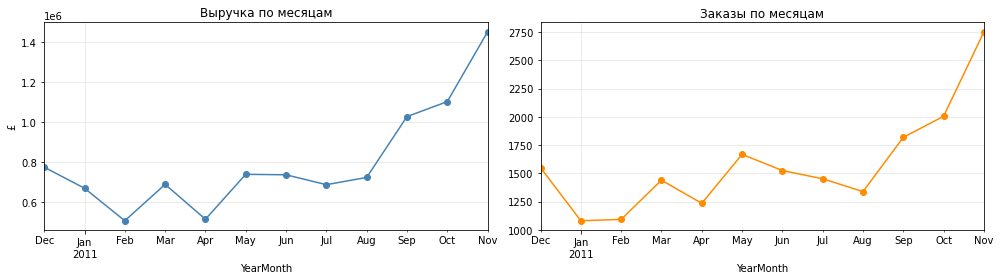

In [21]:
# Визуализируем распределение выручки и заказов по месяцам
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly['revenue'].plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Выручка по месяцам')
axes[0].set_ylabel('£')
axes[0].grid(alpha=0.3)

monthly['orders'].plot(ax=axes[1], marker='o', color='darkorange')
axes[1].set_title('Заказы по месяцам')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Распределение выручки по SKU
sku_rev = df_period.groupby('StockCode')['Revenue'].sum().sort_values(ascending=False)

# Топ-10 товаров
print('Топ-10 SKU по выручке:')
print(sku_rev.head(10))

# Доля топ-SKU
total = sku_rev.sum()
print('\nДоля топ-10 SKU: {:.1%}'.format(sku_rev.head(10).sum() / total))
print('Доля топ-50 SKU: {:.1%}'.format(sku_rev.head(50).sum() / total))
print('Доля топ-100 SKU: {:.1%}'.format(sku_rev.head(100).sum() / total))

Топ-10 SKU по выручке:
StockCode
22423     168162.42
85123A    102236.34
47566      98526.75
85099B     91932.91
23166      81448.21
22086      58007.83
23084      57241.57
84879      56764.88
79321      51456.62
22502      51408.77
Name: Revenue, dtype: float64

Доля топ-10 SKU: 8.5%
Доля топ-50 SKU: 20.9%
Доля топ-100 SKU: 31.9%


Выручка за период: £9 632 333, продано 5 248 634 единиц товара.   
3 897 уникальных SKU, 18 957 заказов, 4 293 покупателя.  
Средний чек £508, медианный £302. Разрыв в 1,7× указывает на «тяжёлый хвост»: несколько крупных оптовых заказов заметно завышают среднее. Для описания «типичного» заказа используем медиану.  
Выраженная сезонность: пик в ноябре (£1,45 млн, 2 751 заказ), спад в феврале (£508 тыс.). Разброс выручки между месяцами почти в 3 раза.  
Рост выручки в высокий сезон идёт преимущественно за счёт числа заказов, а не размера чека (средний чек колеблется в диапазоне £417–620).  
Концентрация выручки: топ-10 SKU — 8,5%, топ-50 — 20,9%, топ-100 — 31,9%. Концентрация умеренная, но выраженная: 2,6% ассортимента дают треть выручки.

## Этап 3. ABC-анализ

In [23]:
# Агрегируем выручку и количество по SKU
abc = df_period.groupby('StockCode').agg(
    Revenue=('Revenue', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique'),
    Description=('Description', 'first'),
).sort_values('Revenue', ascending=False).reset_index()

# Доля и накопительная доля
total_rev = abc['Revenue'].sum()
abc['Revenue_share'] = abc['Revenue'] / total_rev
abc['Cum_share'] = abc['Revenue_share'].cumsum()

abc.head(10)

,StockCode,Revenue,Quantity,Orders,Customers,Description,Revenue_share,Cum_share
0,22423,168162.42,13402,1929,873,REGENCY CAKESTAND 3 TIER,0.017458,0.017458
1,85123A,102236.34,36826,2132,850,WHITE HANGING HEART T-LIGHT HOLDER,0.010614,0.028072
2,47566,98526.75,18147,1657,705,PARTY BUNTING,0.010229,0.038301
3,85099B,91932.91,47266,2036,625,JUMBO BAG RED RETROSPOT,0.009544,0.047845
4,23166,81448.21,77826,233,135,MEDIUM CERAMIC TOP STORAGE JAR,0.008456,0.056301
5,22086,58007.83,17241,1044,591,PAPER CHAIN KIT 50'S CHRISTMAS,0.006022,0.062323
6,23084,57241.57,26435,867,413,RABBIT NIGHT LIGHT,0.005943,0.068265
7,84879,56764.88,35032,1408,666,ASSORTED COLOUR BIRD ORNAMENT,0.005893,0.074159
8,79321,51456.62,9840,630,202,CHILLI LIGHTS,0.005342,0.079501
9,22502,51408.77,1937,463,175,PICNIC BASKET WICKER SMALL,0.005337,0.084838


In [24]:
# Присваиваем категории A / B / C
def abc_class(cum_share):
    if cum_share <= 0.80:
        return 'A'
    elif cum_share <= 0.95:
        return 'B'
    else:
        return 'C'

abc['ABC'] = abc['Cum_share'].apply(abc_class)
abc.head(10)

,StockCode,Revenue,Quantity,Orders,Customers,Description,Revenue_share,Cum_share,ABC
0,22423,168162.42,13402,1929,873,REGENCY CAKESTAND 3 TIER,0.017458,0.017458,A
1,85123A,102236.34,36826,2132,850,WHITE HANGING HEART T-LIGHT HOLDER,0.010614,0.028072,A
2,47566,98526.75,18147,1657,705,PARTY BUNTING,0.010229,0.038301,A
3,85099B,91932.91,47266,2036,625,JUMBO BAG RED RETROSPOT,0.009544,0.047845,A
4,23166,81448.21,77826,233,135,MEDIUM CERAMIC TOP STORAGE JAR,0.008456,0.056301,A
5,22086,58007.83,17241,1044,591,PAPER CHAIN KIT 50'S CHRISTMAS,0.006022,0.062323,A
6,23084,57241.57,26435,867,413,RABBIT NIGHT LIGHT,0.005943,0.068265,A
7,84879,56764.88,35032,1408,666,ASSORTED COLOUR BIRD ORNAMENT,0.005893,0.074159,A
8,79321,51456.62,9840,630,202,CHILLI LIGHTS,0.005342,0.079501,A
9,22502,51408.77,1937,463,175,PICNIC BASKET WICKER SMALL,0.005337,0.084838,A


In [25]:
# Смотрим сводку по категориям
summary = abc.groupby('ABC').agg(
    SKU=('StockCode', 'count'),
    Revenue=('Revenue', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Orders', 'sum'),
).reset_index()

summary['SKU_share_%']  = summary['SKU'] / summary['SKU'].sum() * 100
summary['Rev_share_%']  = summary['Revenue'] / summary['Revenue'].sum() * 100
summary['Qty_share_%']  = summary['Quantity'] / summary['Quantity'].sum() * 100

summary = summary[['ABC', 'SKU', 'SKU_share_%', 'Revenue', 'Rev_share_%', 'Quantity', 'Qty_share_%']]
summary.round(2)

,ABC,SKU,SKU_share_%,Revenue,Rev_share_%,Quantity,Qty_share_%
0,A,832,21.35,7705104.81,79.99,3564111,67.91
1,B,977,25.07,1445134.83,15.00,1203537,22.93
2,C,2088,53.58,482093.60,5.00,480986,9.16


In [26]:
# Товары в категориях
print('Примеры A:')
print(abc[abc['ABC'] == 'A'].head(5)[['StockCode', 'Description', 'Revenue', 'Cum_share']])

print('\nПримеры B:')
print(abc[abc['ABC'] == 'B'].head(5)[['StockCode', 'Description', 'Revenue', 'Cum_share']])

print('\nПримеры C:')
print(abc[abc['ABC'] == 'C'].head(5)[['StockCode', 'Description', 'Revenue', 'Cum_share']])

Примеры A:
  StockCode                         Description    Revenue  Cum_share
0     22423            REGENCY CAKESTAND 3 TIER  168162.42   0.017458
1    85123A  WHITE HANGING HEART T-LIGHT HOLDER  102236.34   0.028072
2     47566                       PARTY BUNTING   98526.75   0.038301
3    85099B             JUMBO BAG RED RETROSPOT   91932.91   0.047845
4     23166      MEDIUM CERAMIC TOP STORAGE JAR   81448.21   0.056301

Примеры B:
    StockCode                         Description  Revenue  Cum_share
832     21781             MA CAMPAGNE CUTLERY BOX  2661.80   0.800197
833     22224              WHITE LOVEBIRD LANTERN  2658.41   0.800473
834     22433         WATERING CAN GREEN DINOSAUR  2651.67   0.800749
835     22329  ROUND CONTAINER SET OF 5 RETROSPOT  2628.97   0.801021
836     22582        PACK OF 6 SWEETIE GIFT BOXES  2623.99   0.801294

Примеры C:
     StockCode                        Description  Revenue  Cum_share
1809    85135C           RED DRAGONFLY HELICOPTER   760

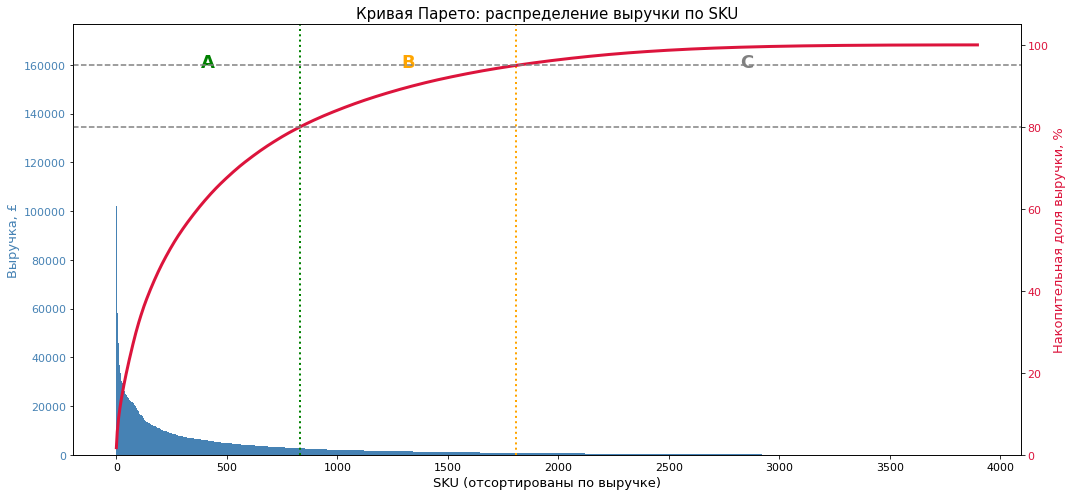

In [27]:
# Строим график Парето 
fig, ax1 = plt.subplots(figsize=(15, 7))

# Столбики — выручка SKU по убыванию
ax1.bar(range(len(abc)), abc['Revenue'], color='steelblue', width=1.0)
ax1.set_xlabel('SKU (отсортированы по выручке)', fontsize=13)
ax1.set_ylabel('Выручка, £', color='steelblue', fontsize=13)
ax1.tick_params(axis='y', labelcolor='steelblue', labelsize=11)
ax1.tick_params(axis='x', labelsize=11)

# Линия — накопительная доля
ax2 = ax1.twinx()
ax2.plot(range(len(abc)), abc['Cum_share'] * 100,
         color='crimson', linewidth=3)
ax2.axhline(80, color='grey', linestyle='--', linewidth=1.5)
ax2.axhline(95, color='grey', linestyle='--', linewidth=1.5)
ax2.set_ylabel('Накопительная доля выручки, %', color='crimson', fontsize=13)
ax2.tick_params(axis='y', labelcolor='crimson', labelsize=11)
ax2.set_ylim(0, 105)

# Вертикальные границы зон A / B / C
n_a = (abc['ABC'] == 'A').sum()
n_b = (abc['ABC'] == 'B').sum()

ax1.axvline(n_a, color='green', linestyle=':', linewidth=2)
ax1.axvline(n_a + n_b, color='orange', linestyle=':', linewidth=2)

# Подписи зон
ax1.text(n_a / 2, ax1.get_ylim()[1] * 0.9, 'A',
         ha='center', fontsize=18, color='green', fontweight='bold')
ax1.text(n_a + n_b / 2, ax1.get_ylim()[1] * 0.9, 'B',
         ha='center', fontsize=18, color='orange', fontweight='bold')
ax1.text(n_a + n_b + (len(abc) - n_a - n_b) / 2, ax1.get_ylim()[1] * 0.9, 'C',
         ha='center', fontsize=18, color='grey', fontweight='bold')

plt.title('Кривая Парето: распределение выручки по SKU', fontsize=15)
plt.tight_layout()
plt.show()

Классическая картина Парето: A — 21,4% SKU дают 80,0% выручки, B — 25,1% SKU дают 15,0%, C — 53,6% SKU дают всего 5,0%.  
По физическим единицам распределение мягче: A — 68%, B — 23%, C — 9%. Это значит, что C-товары дешевле среднего (низкая цена → малый вклад в выручку при сопоставимом объёме продаж).  
Границы: A — накопительная доля до 80% (832 SKU); B — от 80% до 95% (977 SKU); C — свыше 95% (2 088 SKU).  
Категория C — не «плохой товар», а низкий вклад в выручку. Решение об удалении возможно только после XYZ-анализа и учёта роли товара в корзине.

## Этап 4. XYZ-анализ

In [28]:
# Строим календарь (12 месяцев × все SKU)
# Все 12 месяцев периода
all_months = pd.period_range('2010-12', '2011-11', freq='M')
print('Месяцев:', len(all_months), '| С какого по какой:', all_months[0], '—', all_months[-1])

# Все уникальные SKU
all_skus = df_period['StockCode'].unique()

# Каждый SKU × каждый месяц
full_index = pd.MultiIndex.from_product(
    [all_skus, all_months],
    names=['StockCode', 'YearMonth']
)
calendar = pd.DataFrame(index=full_index).reset_index()
print('Каркас:', calendar.shape, '=', len(all_skus), 'SKU × 12 месяцев')
calendar.head()

Месяцев: 12 | С какого по какой: 2010-12 — 2011-11
Каркас: (46764, 2) = 3897 SKU × 12 месяцев


,StockCode,YearMonth
0,85123A,2010-12
1,85123A,2011-01
2,85123A,2011-02
3,85123A,2011-03
4,85123A,2011-04


In [29]:
# Месячные продажи по SKU
monthly_qty = df_period.groupby(['StockCode', 'YearMonth'])['Quantity'].sum().reset_index()
monthly_qty.head()

,StockCode,YearMonth,Quantity
0,10002,2010-12,251
1,10002,2011-01,340
2,10002,2011-02,52
3,10002,2011-03,28
4,10002,2011-04,189


In [30]:
# LEFT JOIN: каркас слева, продажи справа → где продаж нет, будет NaN
xyz = calendar.merge(monthly_qty, on=['StockCode', 'YearMonth'], how='left')

# NaN → 0: товар не продавался в этот месяц
xyz['Quantity'] = xyz['Quantity'].fillna(0)

print('После merge:', xyz.shape)
print('Нулевых месяцев:', (xyz['Quantity'] == 0).sum(), 'из', len(xyz))
xyz.head(15)

После merge: (46764, 3)
Нулевых месяцев: 15272 из 46764


,StockCode,YearMonth,Quantity
0,85123A,2010-12,3752.0
1,85123A,2011-01,5527.0
2,85123A,2011-02,1877.0
3,85123A,2011-03,1998.0
4,85123A,2011-04,3843.0
5,85123A,2011-05,4006.0
6,85123A,2011-06,1675.0
7,85123A,2011-07,3006.0
8,85123A,2011-08,2075.0
9,85123A,2011-09,2474.0


In [31]:
# Считаем CV для каждого SKU
xyz_stats = xyz.groupby('StockCode')['Quantity'].agg(
    Mean='mean',
    Std='std',
    Months_Active=lambda s: (s > 0).sum(),   # сколько месяцев с продажами
    Total_Qty='sum'
).reset_index()

# CV = std / mean (защита от деления на ноль)
xyz_stats['CV'] = xyz_stats['Std'] / xyz_stats['Mean'].replace(0, np.nan)

# Товары, которые не продавались ни разу (маловероятно, но проверим)
print('SKU с mean=0:', (xyz_stats['Mean'] == 0).sum())

xyz_stats.head(10)

SKU с mean=0: 0


,StockCode,Mean,Std,Months_Active,Total_Qty,CV
0,10002,71.666667,119.154852,5,860.0,1.662626
1,10080,25.250000,33.092501,7,303.0,1.310594
2,10120,15.500000,16.284404,9,186.0,1.050607
3,10125,105.750000,70.728836,11,1269.0,0.668831
4,10133,238.000000,295.301079,10,2856.0,1.240761
5,10135,180.000000,176.955053,12,2160.0,0.983084
6,11001,132.750000,132.507375,12,1593.0,0.998172
7,15030,11.750000,25.201461,7,141.0,2.144805
8,15034,549.083333,589.255225,12,6589.0,1.073162
9,15036,1979.750000,1416.019011,12,23757.0,0.715251


In [32]:
# Присваиваем категории X / Y / Z
def xyz_class(cv):
    if pd.isna(cv):
        return 'Z'         
    if cv <= 0.5:
        return 'X'
    elif cv <= 1.0:
        return 'Y'
    else:
        return 'Z'

xyz_stats['XYZ'] = xyz_stats['CV'].apply(xyz_class)

print(xyz_stats['XYZ'].value_counts())

Z    2513
Y    1062
X     322
Name: XYZ, dtype: int64


In [33]:
# Распределение CV
xyz_stats['CV'].describe()

count    3897.000000
mean        1.467751
std         0.849883
min         0.172358
25%         0.798937
50%         1.283495
75%         1.927669
max         3.464102
Name: CV, dtype: float64

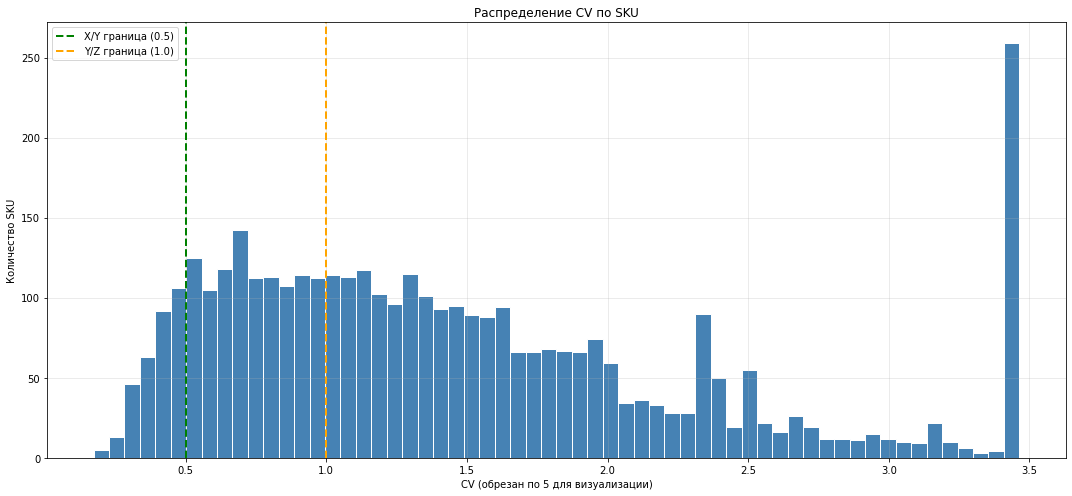

In [34]:
fig, ax = plt.subplots(figsize=(15, 7))
xyz_stats['CV'].clip(upper=5).hist(bins=60, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(0.5, color='green', linestyle='--', linewidth=2, label='X/Y граница (0.5)')
ax.axvline(1.0, color='orange', linestyle='--', linewidth=2, label='Y/Z граница (1.0)')
ax.set_xlabel('CV (обрезан по 5 для визуализации)')
ax.set_ylabel('Количество SKU')
ax.set_title('Распределение CV по SKU')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Сводка по категориям X / Y / Z
xyz_summary = xyz_stats.groupby('XYZ').agg(
    SKU=('StockCode', 'count'),
    Mean_Qty=('Mean', 'mean'),
    Mean_ActiveMonths=('Months_Active', 'mean'),
).reset_index()

xyz_summary['SKU_share_%'] = xyz_summary['SKU'] / xyz_summary['SKU'].sum() * 100
xyz_summary.round(2)

,XYZ,SKU,Mean_Qty,Mean_ActiveMonths,SKU_share_%
0,X,322,372.45,11.99,8.26
1,Y,1062,158.29,11.28,27.25
2,Z,2513,59.43,6.23,64.49


In [36]:
# Сколько SKU с одним активным месяцем
print('SKU с 1 активным месяцем:', (xyz_stats['Months_Active'] == 1).sum())
print('SKU с 2 активными месяцами:', (xyz_stats['Months_Active'] == 2).sum())
print('SKU с >=6 активными месяцами:', (xyz_stats['Months_Active'] >= 6).sum())

# Проверим: у всех ли с одним месяцем CV = 3.464
one_month = xyz_stats[xyz_stats['Months_Active'] == 1]
print('\nУникальные значения CV у SKU с 1 месяцем:')
print(one_month['CV'].round(4).value_counts().head())

SKU с 1 активным месяцем: 257
SKU с 2 активными месяцами: 266
SKU с >=6 активными месяцами: 2788

Уникальные значения CV у SKU с 1 месяцем:
3.4641    257
Name: CV, dtype: int64


In [37]:
# Z-товары с 10+ активными месяцами
seasonal_z = xyz_stats[(xyz_stats['XYZ'] == 'Z') & (xyz_stats['Months_Active'] >= 10)]
print('Z с 10+ активными месяцами:', len(seasonal_z))
seasonal_z.sort_values('Total_Qty', ascending=False).head(10)

Z с 10+ активными месяцами: 608


,StockCode,Mean,Std,Months_Active,Total_Qty,CV,XYZ
931,22086,1436.750000,2341.354896,12,17241.0,1.629619,Z
1742,22952,1275.500000,1695.023491,12,15306.0,1.328909,Z
15,16014,1104.833333,1200.985870,12,13258.0,1.087029,Z
2597,84568,1024.666667,1068.965544,12,12296.0,1.043232,Z
63,20668,950.750000,1310.896163,12,11409.0,1.378802,Z
213,20971,884.416667,1314.585207,12,10613.0,1.486387,Z
292,21108,836.083333,1284.528740,12,10033.0,1.536364,Z
1380,22577,824.000000,1589.186356,12,9888.0,1.928624,Z
1700,22910,811.083333,1169.069285,12,9733.0,1.441368,Z
2572,84347,714.166667,1102.880595,12,8570.0,1.544290,Z


In [38]:
# Сделаем точную разбивку внутри Z
z = xyz_stats[xyz_stats['XYZ'] == 'Z'].copy()

z['Z_subgroup'] = pd.cut(
    z['Months_Active'],
    bins=[0, 2, 5, 9, 12],
    labels=['редкие (1-2 мес)', 'низкочастотные (3-5)', 'средние (6-9)', 'сезонные (10-12)']
)

z['Z_subgroup'].value_counts()

средние (6-9)           796
сезонные (10-12)        608
низкочастотные (3-5)    586
редкие (1-2 мес)        523
Name: Z_subgroup, dtype: int64

In [39]:
# Подтянем выручку из ABC-таблицы
z_with_rev = z.merge(abc[['StockCode', 'Revenue']], on='StockCode', how='left')

z_with_rev.groupby('Z_subgroup').agg(
    SKU=('StockCode', 'count'),
    Revenue=('Revenue', 'sum'),
    Total_Qty=('Total_Qty', 'sum'),
).assign(
    Rev_share=lambda x: x['Revenue'] / x['Revenue'].sum() * 100,
    SKU_share=lambda x: x['SKU'] / x['SKU'].sum() * 100
).round(2)

,SKU,Revenue,Total_Qty,Rev_share,SKU_share
Z_subgroup,,,,,
редкие (1-2 мес),523,211278.97,64818.0,6.46,20.81
низкочастотные (3-5),586,432535.70,255090.0,13.22,23.32
средние (6-9),796,1339636.07,721382.0,40.96,31.68
сезонные (10-12),608,1287432.43,751007.0,39.36,24.19


Распределение:

X — 322 SKU (8,3%): стабильный спрос, CV ≤ 0,5, в среднем 12 активных месяцев.

Y — 1 062 SKU (27,3%): умеренная вариативность, 0,5 < CV ≤ 1, в среднем 11 активных месяцев.

Z — 2 513 SKU (64,5%): сильная вариативность, CV > 1, в среднем 6,2 активных месяца.

Артефакт CV: 257 SKU с одним активным месяцем имеют CV = 3,4641 — это математическое следствие формулы, а не реальная «сверхнестабильность». Такие SKU корректнее называть редкими, а не аномально волатильными.

Z неоднородна — ключевой вывод:

Редкие (1–2 мес): 523 SKU → 6,5% выручки Z (~2,2% выручки магазина).

Низкочастотные (3–5 мес): 586 SKU → 13,2% выручки Z.

Средние (6–9 мес): 796 SKU → 41,0% выручки Z.

Сезонные (10–12 мес): 608 SKU → 39,4% выручки Z.

Практический вывод: Z — не список на удаление. Основной пул кандидатов — редкие (523 SKU, 6,5% выручки Z) и частично низкочастотные Z. Средние и сезонные — держим и планируем запас. Пороговые значения CV (0,5 и 1,0) стандартные, распределение CV их подтверждает.

## Этап 5. Объединенная матрица ABC/XYZ

In [40]:
# Обе таблицы индексируем по StockCode и соединяем
matrix = abc.merge(
    xyz_stats[['StockCode', 'Mean', 'Std', 'Months_Active', 'CV', 'XYZ']],
    on='StockCode',
    how='inner'   # inner: оставляем только SKU, которые есть в обоих анализах
)

# Комбинированная группа
matrix['ABC_XYZ'] = matrix['ABC'] + matrix['XYZ']

print('Всего SKU в матрице:', len(matrix))
print('Проверка: сумма по 9 группам должна равняться', len(matrix))
matrix.head()

Всего SKU в матрице: 3897
Проверка: сумма по 9 группам должна равняться 3897


,StockCode,Revenue,Quantity,Orders,Customers,Description,Revenue_share,Cum_share,ABC,Mean,Std,Months_Active,CV,XYZ,ABC_XYZ
0,22423,168162.42,13402,1929,873,REGENCY CAKESTAND 3 TIER,0.017458,0.017458,A,1116.833333,357.694850,12,0.320276,X,AX
1,85123A,102236.34,36826,2132,850,WHITE HANGING HEART T-LIGHT HOLDER,0.010614,0.028072,A,3068.833333,1319.085278,12,0.429833,X,AX
2,47566,98526.75,18147,1657,705,PARTY BUNTING,0.010229,0.038301,A,1512.250000,990.174560,12,0.654769,Y,AY
3,85099B,91932.91,47266,2036,625,JUMBO BAG RED RETROSPOT,0.009544,0.047845,A,3938.833333,1299.500102,12,0.329920,X,AX
4,23166,81448.21,77826,233,135,MEDIUM CERAMIC TOP STORAGE JAR,0.008456,0.056301,A,6485.500000,21331.278995,8,3.289072,Z,AZ


In [41]:
# Сводная таблица по 9 группам
matrix_summary = matrix.groupby('ABC_XYZ').agg(
    SKU=('StockCode', 'count'),
    Revenue=('Revenue', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Orders', 'sum'),
    Customers=('Customers', 'sum'),
    Avg_ActiveMonths=('Months_Active', 'mean'),
    Avg_Price=('Revenue', lambda s: 0),   # placeholder, пересчитаем ниже
).reset_index()

# Доли
total_sku = matrix_summary['SKU'].sum()
total_rev = matrix_summary['Revenue'].sum()
total_qty = matrix_summary['Quantity'].sum()

matrix_summary['SKU_share_%'] = matrix_summary['SKU'] / total_sku * 100
matrix_summary['Rev_share_%'] = matrix_summary['Revenue'] / total_rev * 100
matrix_summary['Qty_share_%'] = matrix_summary['Quantity'] / total_qty * 100

# Средняя цена = выручка / количество
matrix_summary['Avg_Price'] = matrix_summary['Revenue'] / matrix_summary['Quantity']

matrix_summary = matrix_summary[[
    'ABC_XYZ', 'SKU', 'SKU_share_%', 'Revenue', 'Rev_share_%',
    'Quantity', 'Qty_share_%', 'Orders', 'Customers',
    'Avg_ActiveMonths', 'Avg_Price'
]]

matrix_summary.round(2)

,ABC_XYZ,SKU,SKU_share_%,Revenue,Rev_share_%,Quantity,Qty_share_%,Orders,Customers,Avg_ActiveMonths,Avg_Price
0,AX,208,5.34,2302543.91,23.90,1271716,24.23,106264,47924,11.99,1.81
1,AY,327,8.39,3214699.34,33.37,1404524,26.76,123617,62133,11.29,2.29
2,AZ,297,7.62,2187861.56,22.71,887871,16.92,76943,47063,7.85,2.46
3,BX,97,2.49,155132.24,1.61,153839,2.93,17440,8723,12.00,1.01
4,BY,361,9.26,538728.67,5.59,472860,9.01,53451,28165,11.60,1.14
5,BZ,519,13.32,751273.92,7.80,576838,10.99,53691,32295,7.92,1.30
6,CX,17,0.44,8243.91,0.09,13591,0.26,1597,889,12.00,0.61
7,CY,374,9.60,142102.00,1.48,139807,2.66,21759,9934,10.95,1.02
8,CZ,1697,43.55,331747.69,3.44,327588,6.24,38119,20615,5.43,1.01


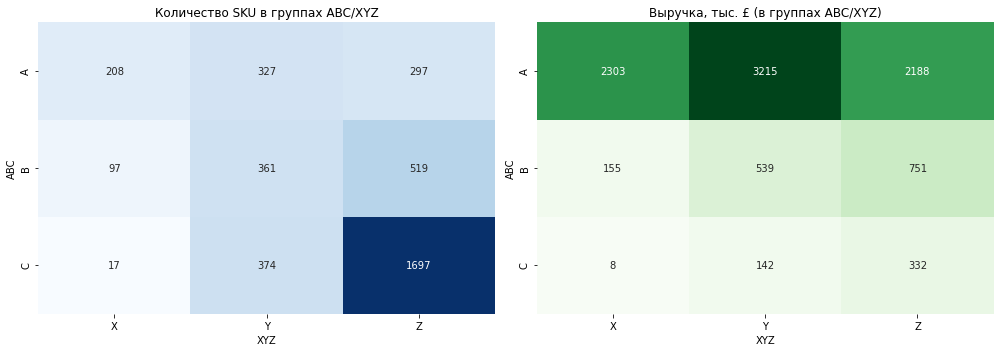

In [42]:
# Сводная матрица по выручке
pivot_rev = matrix_summary.pivot_table(
    index='ABC_XYZ', values='Revenue', aggfunc='sum'
)

# Разложим на ABC × XYZ
matrix_summary['ABC_only'] = matrix_summary['ABC_XYZ'].str[0]
matrix_summary['XYZ_only'] = matrix_summary['ABC_XYZ'].str[1]

heat_sku = matrix_summary.pivot_table(
    index='ABC_only', columns='XYZ_only', values='SKU', aggfunc='sum'
).reindex(index=['A','B','C'], columns=['X','Y','Z'])

heat_rev = matrix_summary.pivot_table(
    index='ABC_only', columns='XYZ_only', values='Revenue', aggfunc='sum'
).reindex(index=['A','B','C'], columns=['X','Y','Z'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(heat_sku, annot=True, fmt='.0f', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Количество SKU в группах ABC/XYZ')
axes[0].set_xlabel('XYZ'); axes[0].set_ylabel('ABC')

sns.heatmap(heat_rev / 1000, annot=True, fmt='.0f', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Выручка, тыс. £ (в группах ABC/XYZ)')
axes[1].set_xlabel('XYZ'); axes[1].set_ylabel('ABC')

plt.tight_layout()
plt.show()

In [43]:
# Топ групп по выручке
matrix_summary.sort_values('Revenue', ascending=False)[
    ['ABC_XYZ', 'SKU', 'SKU_share_%', 'Revenue', 'Rev_share_%', 'Avg_ActiveMonths', 'Avg_Price']
].round(2)

,ABC_XYZ,SKU,SKU_share_%,Revenue,Rev_share_%,Avg_ActiveMonths,Avg_Price
1,AY,327,8.39,3214699.34,33.37,11.29,2.29
0,AX,208,5.34,2302543.91,23.90,11.99,1.81
2,AZ,297,7.62,2187861.56,22.71,7.85,2.46
5,BZ,519,13.32,751273.92,7.80,7.92,1.30
4,BY,361,9.26,538728.67,5.59,11.60,1.14
8,CZ,1697,43.55,331747.69,3.44,5.43,1.01
3,BX,97,2.49,155132.24,1.61,12.00,1.01
7,CY,374,9.60,142102.00,1.48,10.95,1.02
6,CX,17,0.44,8243.91,0.09,12.00,0.61


A-строка (832 SKU, 21% ассортимента) даёт 80,0% выручки. Внутри неё AX, AY, AZ делят деньги примерно поровну, но принципиально разные по стабильности: AX — стабильные хиты, AY — сезонные, AZ — волатильные.

CZ — эпицентр ассортиментного «балласта»: 1 697 SKU (43,6% ассортимента) дают 3,4% выручки. Но внутри CZ смешаны редкие и сезонные товары — слепое удаление недопустимо.

Группа CX (17 SKU, 0,09% выручки) — нетипичная: стабильные по спросу, но дешёвые. Это, скорее всего, расходники/дополнения. Трогать не рекомендуется.

BZ (519 SKU, 7,8% выручки) — пограничная зона: часть можно рассмотреть на оптимизацию, но осторожно.

Дисбаланс SKU и выручки максимален в нижнем правом углу матрицы (CZ). Это и есть «склад хвоста».

## Этап 6. Интерпретация и стратегия управления

In [44]:
# Добавляем колонки необходимые для стратегии
strategy = matrix_summary.copy()

# Доля выручки на 1 SKU — «цена» одного товара в группе для бизнеса
strategy['Rev_per_SKU'] = strategy['Revenue'] / strategy['SKU']

# Доля заказов на 1 SKU — как часто товар встречается
strategy['Orders_per_SKU'] = strategy['Orders'] / strategy['SKU']

# Доля покупателей на 1 SKU
strategy['Customers_per_SKU'] = strategy['Customers'] / strategy['SKU']

# Разница: доля выручки минус доля SKU. Положительная — группа «недооценена» по ресурсам
strategy['Rev_minus_SKU'] = strategy['Rev_share_%'] - strategy['SKU_share_%']

strategy = strategy[[
    'ABC_XYZ', 'SKU', 'SKU_share_%', 'Revenue', 'Rev_share_%',
    'Rev_per_SKU', 'Orders_per_SKU', 'Customers_per_SKU',
    'Avg_ActiveMonths', 'Avg_Price', 'Rev_minus_SKU'
]]

strategy.sort_values('Rev_share_%', ascending=False).round(2)

,ABC_XYZ,SKU,SKU_share_%,Revenue,Rev_share_%,Rev_per_SKU,Orders_per_SKU,Customers_per_SKU,Avg_ActiveMonths,Avg_Price,Rev_minus_SKU
1,AY,327,8.39,3214699.34,33.37,9830.88,378.03,190.01,11.29,2.29,24.98
0,AX,208,5.34,2302543.91,23.90,11069.92,510.88,230.40,11.99,1.81,18.57
2,AZ,297,7.62,2187861.56,22.71,7366.54,259.07,158.46,7.85,2.46,15.09
5,BZ,519,13.32,751273.92,7.80,1447.54,103.45,62.23,7.92,1.30,-5.52
4,BY,361,9.26,538728.67,5.59,1492.32,148.06,78.02,11.60,1.14,-3.67
8,CZ,1697,43.55,331747.69,3.44,195.49,22.46,12.15,5.43,1.01,-40.10
3,BX,97,2.49,155132.24,1.61,1599.30,179.79,89.93,12.00,1.01,-0.88
7,CY,374,9.60,142102.00,1.48,379.95,58.18,26.56,10.95,1.02,-8.12
6,CX,17,0.44,8243.91,0.09,484.94,93.94,52.29,12.00,0.61,-0.35


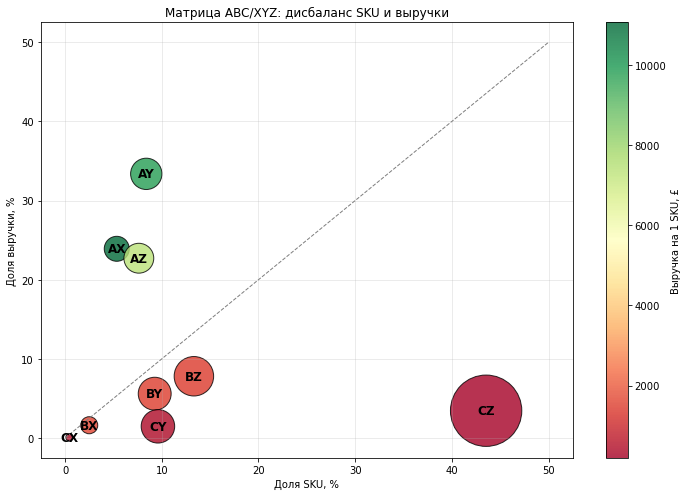

In [45]:
fig, ax = plt.subplots(figsize=(10, 7))

# Диагональная линия «SKU = выручка»
ax.plot([0, 50], [0, 50], color='grey', linestyle='--', linewidth=1)

# Точки групп
scatter = ax.scatter(
    strategy['SKU_share_%'], strategy['Rev_share_%'],
    s=strategy['SKU'] * 3,                  # размер точки = число SKU
    c=strategy['Rev_per_SKU'],              # цвет = выручка на SKU
    cmap='RdYlGn', edgecolor='black', alpha=0.8
)

# Подписи групп
for _, row in strategy.iterrows():
    ax.annotate(row['ABC_XYZ'],
                (row['SKU_share_%'], row['Rev_share_%']),
                fontsize=12, ha='center', va='center', fontweight='bold')

ax.set_xlabel('Доля SKU, %')
ax.set_ylabel('Доля выручки, %')
ax.set_title('Матрица ABC/XYZ: дисбаланс SKU и выручки')
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Выручка на 1 SKU, £')

plt.tight_layout()
plt.show()

Стратегия опирается на три показателя из matrix_summary: долю выручки, долю ассортимента и среднее число активных месяцев. Ниже — по каждой группе: что она собой представляет по данным и как ей управлять.

**AX** — 208 SKU, 23,9% выручки, 12,0 активных месяцев.
Стабильные хиты. Каждый SKU приносит в среднем £11 070 выручки и встречается примерно в 511 заказах. Спрос ровный, без провалов.
Стратегия: приоритет наличия. Никогда не допускать out-of-stock, регулярный автозаказ, минимальный страховой запас, контроль дефицита.

**AY** — 327 SKU, 33,4% выручки, 11,3 активных месяцев.
Крупнейшая по деньгам группа. В среднем £9 831 на SKU и ~378 заказов. Продажи регулярны, но с сезонной амплитудой.
Стратегия: держать запас с учётом сезонности. Планировать объёмы под пики (сентябрь–ноябрь) и спады (январь–февраль), регулярный мониторинг колебаний.

**AZ** — 297 SKU, 22,7% выручки, 7,9 активных месяцев.
Дорогие, но нерегулярные хиты. £7 366 на SKU, но продаются только ~8 месяцев из 12. Возможны крупные разовые заказы.
Стратегия: осторожный запас, закупка под спрос. Не держать много на складе, отдельное планирование по каждому SKU, учитывать крупные разовые заказы.

**BX** — 97 SKU, 1,6% выручки, 12,0 активных месяцев.
Стабильные, но малодоходные. £1 599 на SKU.
Стратегия: стандартное управление. Небольшой запас, автозаказ. Не приоритет, но и не кандидат на сокращение.

**BY** — 361 SKU, 5,6% выручки, 11,6 активных месяцев.
Средние и стабильные. £1 492 на SKU.
Стратегия: стандартное управление, минимальный страховой резерв, мониторинг раз в квартал.

**BZ** — 519 SKU, 7,8% выручки, 7,9 активных месяцев.
Средние по деньгам, но нерегулярные. £1 447 на SKU.
Стратегия: ограниченный запас или дополнительное исследование. Внутри группы разделять сезонные (держать) и редкие (кандидаты на проверку).

**CX** — 17 SKU, 0,09% выручки, 12,0 активных месяцев.
Мизерная выручка, но стабильный спрос. £485 на SKU.
Стратегия: проверить роль в ассортименте. Скорее всего расходники или дополнения к основным покупкам. Не удалять автоматически — могут быть нужны как «довесок» к заказу.

**CY** — 374 SKU, 1,5% выручки, 10,95 активных месяцев.
Низкая выручка, но стабильные продажи. £380 на SKU.
Стратегия: проверить дополнительные метрики и роль товара. Рассматривать индивидуально, а не массово.

**CZ** — 1 697 SKU, 3,4% выручки, 5,4 активных месяцев.
Основной «балласт» ассортимента. £196 на SKU и всего ~22 заказа на SKU. Доля SKU (43,6%) в 13 раз больше доли выручки (3,4%).
Стратегия: главный пул для разбора, но не список на удаление. Внутри CZ смешаны редкие (кандидаты на вывод) и сезонные (не трогать). Разделять по числу активных месяцев и абсолютной выручке.

Общий вывод.
Удаление в группе A недопустимо — это 80% выручки. В группе B — требует обоснования. В группе C — только после проверки роли товара и его подгруппы (сезонный / редкий). Ключевой индикатор дисбаланса — доля выручки минус доля SKU: у CZ он максимально отрицательный.

## Этап 7. Формулировка списка кандидатов на сокращение

In [46]:
cand = matrix.copy()

# Дополнительные метрики
cand['Rev_per_SKU'] = cand['Revenue'] / 1   # оставим, если понадобится
cand['Avg_Price'] = cand['Revenue'] / cand['Quantity']
cand['ActiveMonths'] = cand['Months_Active']
cand['Order_Freq'] = cand['Orders']            # сколько заказов содержат SKU
cand['Customer_Freq'] = cand['Customers']

# Доля выручки товара
cand['Rev_share_%'] = cand['Revenue'] / cand['Revenue'].sum() * 100

# Возраст товара — сколько месяцев из 12 он присутствует в продажах
# (у нас это ActiveMonths = Months_Active)

cand.head()

,StockCode,Revenue,Quantity,Orders,Customers,Description,Revenue_share,Cum_share,ABC,Mean,...,Months_Active,CV,XYZ,ABC_XYZ,Rev_per_SKU,Avg_Price,ActiveMonths,Order_Freq,Customer_Freq,Rev_share_%
0,22423,168162.42,13402,1929,873,REGENCY CAKESTAND 3 TIER,0.017458,0.017458,A,1116.833333,...,12,0.320276,X,AX,168162.42,12.547562,12,1929,873,1.745812
1,85123A,102236.34,36826,2132,850,WHITE HANGING HEART T-LIGHT HOLDER,0.010614,0.028072,A,3068.833333,...,12,0.429833,X,AX,102236.34,2.776200,12,2132,850,1.061387
2,47566,98526.75,18147,1657,705,PARTY BUNTING,0.010229,0.038301,A,1512.250000,...,12,0.654769,Y,AY,98526.75,5.429368,12,1657,705,1.022875
3,85099B,91932.91,47266,2036,625,JUMBO BAG RED RETROSPOT,0.009544,0.047845,A,3938.833333,...,12,0.329920,X,AX,91932.91,1.945011,12,2036,625,0.954420
4,23166,81448.21,77826,233,135,MEDIUM CERAMIC TOP STORAGE JAR,0.008456,0.056301,A,6485.500000,...,8,3.289072,Z,AZ,81448.21,1.046542,8,233,135,0.845571


In [47]:
# Кандидаты — только CZ и BZ
cand['pool'] = cand['ABC_XYZ'].isin(['CZ', 'BZ'])

In [48]:
# Сезонные (10-12 мес) и средние (6-9 мес) не трогаем — это рабочая часть ассортимента
cand['is_low_active'] = cand['ActiveMonths'] < 6

In [49]:
# Товар с выручкой > £1000/год — не кандидат, даже если редкий
cand['is_low_revenue'] = cand['Revenue'] < 1000

In [50]:
# Товар купили > 50 разных клиентов — есть спрос, не трогаем
cand['is_narrow'] = cand['Customers'] < 50

In [51]:
cand['candidate'] = (
    cand['pool'] &
    cand['is_low_active'] &
    cand['is_low_revenue'] &
    cand['is_narrow']
)

In [52]:
n_total = len(cand)
n_cand = cand['candidate'].sum()
print(f'Всего SKU: {n_total}')
print(f'Кандидатов на сокращение: {n_cand} ({n_cand/n_total:.1%})')

# Выручка кандидатов
cand_rev = cand.loc[cand['candidate'], 'Revenue'].sum()
total_rev = cand['Revenue'].sum()
print(f'Выручка кандидатов: £{cand_rev:,.0f} ({cand_rev/total_rev:.2%} от общей)')

# Разбивка по группам
cand[cand['candidate']].groupby('ABC_XYZ').agg(
    SKU=('StockCode', 'count'),
    Revenue=('Revenue', 'sum'),
).sort_values('SKU', ascending=False)

Всего SKU: 3897
Кандидатов на сокращение: 929 (23.8%)
Выручка кандидатов: £109,364 (1.14% от общей)


,SKU,Revenue
ABC_XYZ,,
CZ,905,88418.49
BZ,24,20945.09


In [53]:
# Воронка фильтров
print('Пул (CZ + BZ):', cand['pool'].sum())
print('+ активность < 6:', (cand['pool'] & cand['is_low_active']).sum())
print('+ выручка < £1000:', (cand['pool'] & cand['is_low_active'] & cand['is_low_revenue']).sum())
print('+ покупатели < 50:', cand['candidate'].sum())

Пул (CZ + BZ): 2216
+ активность < 6: 1042
+ выручка < £1000: 946
+ покупатели < 50: 929


In [54]:
# Финальная таблица кандидатов
cand_table = cand[cand['candidate']].copy()

cand_table = cand_table[[
    'StockCode', 'Description', 'ABC', 'XYZ', 'ABC_XYZ',
    'Revenue', 'Rev_share_%', 'Quantity',
    'Orders', 'Customers', 'ActiveMonths', 'Avg_Price'
]]

# Сортируем по выручке — от «крупных кандидатов» к «мелким»
cand_table = cand_table.sort_values('Revenue', ascending=False).reset_index(drop=True)

cand_table['Recommendation'] = 'Проверить на вывод: редкий, низкая выручка, узкая клиентская база'

cand_table.head(20)

,StockCode,Description,ABC,XYZ,ABC_XYZ,Revenue,Rev_share_%,Quantity,Orders,Customers,ActiveMonths,Avg_Price,Recommendation
0,22242,5 HOOK HANGER MAGIC TOADSTOOL,B,Z,BZ,994.38,0.010323,640,34,23,3,1.553719,"Проверить на вывод: редкий, низкая выручка, уз..."
1,23544,WALL ART MID CENTURY MODERN,B,Z,BZ,983.13,0.010207,159,16,15,2,6.183208,"Проверить на вывод: редкий, низкая выручка, уз..."
2,85064,CREAM SWEETHEART LETTER RACK,B,Z,BZ,976.25,0.010135,215,30,20,2,4.540698,"Проверить на вывод: редкий, низкая выручка, уз..."
3,23517,EMBROIDERED RIBBON REEL REBECCA,B,Z,BZ,970.36,0.010074,326,60,48,3,2.976564,"Проверить на вывод: редкий, низкая выручка, уз..."
4,23518,EMBROIDERED RIBBON REEL RACHEL,B,Z,BZ,963.07,0.009998,355,43,39,3,2.712873,"Проверить на вывод: редкий, низкая выручка, уз..."
5,23512,EMBROIDERED RIBBON REEL ROSIE,B,Z,BZ,948.23,0.009844,488,51,42,3,1.943094,"Проверить на вывод: редкий, низкая выручка, уз..."
6,23533,WALL ART GARDEN HAVEN,B,Z,BZ,947.64,0.009838,195,30,21,2,4.859692,"Проверить на вывод: редкий, низкая выручка, уз..."
7,21717,EASTER TIN BUCKET,B,Z,BZ,946.93,0.009831,408,41,34,4,2.320907,"Проверить на вывод: редкий, низкая выручка, уз..."
8,23566,EGG CUP MILKMAID HEIDI,B,Z,BZ,945.31,0.009814,703,71,42,2,1.344680,"Проверить на вывод: редкий, низкая выручка, уз..."
9,23540,WALL ART THE MAGIC FOREST,B,Z,BZ,944.51,0.009806,149,13,8,2,6.338993,"Проверить на вывод: редкий, низкая выручка, уз..."


In [55]:
cand_table.to_excel('candidates_to_review.xlsx', index=False)
print('Сохранено:', len(cand_table), 'SKU в candidates_to_review.xlsx')

Сохранено: 929 SKU в candidates_to_review.xlsx


Критерии отбора (4 фильтра, все должны выполняться одновременно):

Пул: группа CZ или BZ (низкая выручка + низкая/средняя активность).

Активность < 6 месяцев из 12 — исключаем сезонные и регулярные.

Выручка < £1 000 за год — исключаем значимые по деньгам редкие товары.

Покупателей < 50 — исключаем товары с широкой клиентской базой.

Результат:

Всего SKU: 3 897.

Кандидатов на сокращение: 929 (23,8% ассортимента).

Их историческая выручка: £109 364 — всего 1,14% от общей выручки магазина.

Из них: CZ — 905 SKU (£88 418), BZ — 24 SKU (£20 945).

Ключевые оговорки:

23,8% — результат применения фильтров. Ужесточение порогов (например, выручка < £500) снизит число кандидатов, но и уменьшит потенциальный эффект. Мягчение порогов увеличит риск удаления нужных товаров.

Из списка исключены сезонные CZ (активность 10–12 мес), средние CZ (6–9 мес), редкие, но дорогие товары (> £1 000), товары с широкой базой (> 50 покупателей).



## Этап 8. Оценка потенциального эффекта

In [56]:
total_sku = len(cand)
cand_sku = cand['candidate'].sum()
total_rev = cand['Revenue'].sum()
cand_rev = cand.loc[cand['candidate'], 'Revenue'].sum()

print('Исходная выборка:')
print(f'  SKU: {total_sku}')
print(f'  Выручка: £{total_rev:,.2f}')
print()
print('Кандидаты на вывод:')
print(f'  SKU: {cand_sku} ({cand_sku/total_sku:.1%} ассортимента)')
print(f'  Выручка: £{cand_rev:,.2f} ({cand_rev/total_rev:.2%} от общей)')
print()
print('Соотношение:')
print(f'  Мы предлагаем вывести {cand_sku/total_sku:.1%} SKU,')
print(f'  на которые приходится {cand_rev/total_rev:.2%} исторической выручки.')

Исходная выборка:
  SKU: 3897
  Выручка: £9,632,333.24

Кандидаты на вывод:
  SKU: 929 (23.8% ассортимента)
  Выручка: £109,363.58 (1.14% от общей)

Соотношение:
  Мы предлагаем вывести 23.8% SKU,
  на которые приходится 1.14% исторической выручки.


In [57]:
effect = cand[cand['candidate']].groupby('ABC_XYZ').agg(
    SKU=('StockCode', 'count'),
    Revenue=('Revenue', 'sum'),
).reset_index()

effect['SKU_share_%'] = effect['SKU'] / total_sku * 100
effect['Rev_share_%'] = effect['Revenue'] / total_rev * 100
effect.round(2)

,ABC_XYZ,SKU,Revenue,SKU_share_%,Rev_share_%
0,BZ,24,20945.09,0.62,0.22
1,CZ,905,88418.49,23.22,0.92


In [58]:
scenarios = []

for rev_threshold in [500, 1000, 1500]:
    for act_threshold in [3, 6, 9]:
        mask = (
            cand['pool'] &
            (cand['ActiveMonths'] < act_threshold) &
            (cand['Revenue'] < rev_threshold) &
            (cand['Customers'] < 50)
        )
        sku_count = mask.sum()
        rev_sum = cand.loc[mask, 'Revenue'].sum()
        scenarios.append({
            'Revenue_<': rev_threshold,
            'ActiveMonths_<': act_threshold,
            'SKU': sku_count,
            'SKU_share_%': sku_count / total_sku * 100,
            'Revenue': rev_sum,
            'Rev_share_%': rev_sum / total_rev * 100,
        })

scenarios_df = pd.DataFrame(scenarios)
scenarios_df.round(2)

,Revenue_<,ActiveMonths_<,SKU,SKU_share_%,Revenue,Rev_share_%
0,500,3,444,11.39,20685.65,0.21
1,500,6,864,22.17,63083.02,0.65
2,500,9,1197,30.72,117795.48,1.22
3,1000,3,474,12.16,42140.58,0.44
4,1000,6,929,23.84,109363.58,1.14
5,1000,9,1325,34.00,205802.56,2.14
6,1500,3,481,12.34,51280.23,0.53
7,1500,6,945,24.25,129020.29,1.34
8,1500,9,1365,35.03,253864.86,2.64


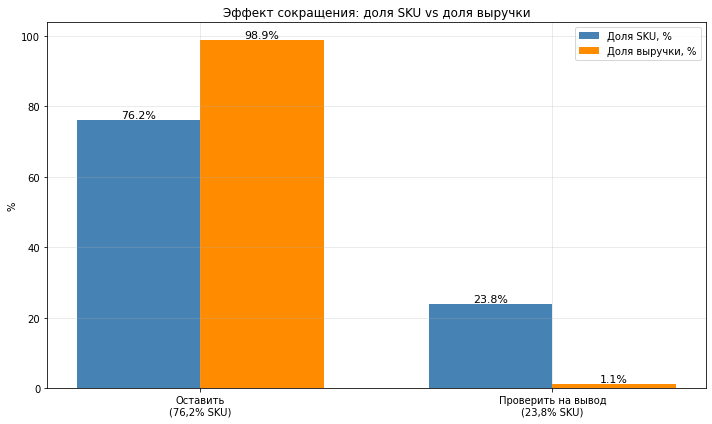

In [59]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ['Оставить\n(76,2% SKU)', 'Проверить на вывод\n(23,8% SKU)']
sku_values = [total_sku - cand_sku, cand_sku]
rev_values = [total_rev - cand_rev, cand_rev]

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, [v/total_sku*100 for v in sku_values],
               width, label='Доля SKU, %', color='steelblue')
bars2 = ax.bar(x + width/2, [v/total_rev*100 for v in rev_values],
               width, label='Доля выручки, %', color='darkorange')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%', (bar.get_x() + bar.get_width()/2, h),
                    ha='center', va='bottom', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('%')
ax.set_title('Эффект сокращения: доля SKU vs доля выручки')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
keep = cand[~cand['candidate']].copy()

keep_summary = keep.groupby('ABC').agg(
    SKU=('StockCode', 'count'),
    Revenue=('Revenue', 'sum'),
).reset_index()

keep_summary['SKU_share_%'] = keep_summary['SKU'] / keep_summary['SKU'].sum() * 100
keep_summary['Rev_share_%'] = keep_summary['Revenue'] / keep_summary['Revenue'].sum() * 100

print('После удаления кандидатов:')
keep_summary.round(2)

После удаления кандидатов:


,ABC,SKU,Revenue,SKU_share_%,Rev_share_%
0,A,832,7705104.81,28.03,80.91
1,B,953,1424189.74,32.11,14.96
2,C,1183,393675.11,39.86,4.13


Главные цифры:

Исходная выборка: 3 897 SKU, £9 632 333 выручки за 12 месяцев.

Кандидатов на вывод: 929 SKU (23,8% ассортимента).

Их историческая выручка: £109 364 (1,14% от общей).

Из них: CZ — 905 SKU (£88 418), BZ — 24 SKU (£20 945).

Интерпретация:

Дисбаланс SKU и выручки колоссальный: четверть ассортимента даёт около 1% денег.

Доля выручки — не «гарантированная потеря». Исторические данные не позволяют предсказать поведение покупателей после удаления. Часть выручки может «перетечь» на замены, часть действительно пропадёт.

Устойчивость решения (сценарный анализ):

При порогах по выручке £500–1 500 и активности 3–9 месяцев доля выручки кандидатов колеблется в узком диапазоне 0,2–2,6%.

Даже заметное изменение порогов не приводит к резкому росту риска.

Наш выбор (£1 000 / 6 мес) — компромисс: близко к бизнес-ориентиру ~20% SKU и низкий риск (~1,1% выручки).

Эффект на оставшийся ассортимент:

A: 832 SKU (28,0% ассортимента) → 80,9% выручки.

B: 953 SKU (32,1%) → 15,0%.

C: 1 183 SKU (39,9%) → 4,1%.

Концентрация не пострадала, ассортимент стал компактнее: доля C по SKU упала с 53,6% до 39,9%.

Что нужно проверить вручную перед изменением ассортимента:

Пограничные случаи — товары с выручкой £800–1 000, активностью 3–5 месяцев, 30+ покупателями.

Серии товаров (например, «EMBROIDERED RIBBON REEL») — решение по серии целиком.

Роль в корзине — кандидаты, встречающиеся в заказах с товарами A, требуют basket-анализа.

Данные об остатках — нулевые продажи могли быть следствием out-of-stock, а не отсутствия спроса.